# Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import shap

df = pd.read_csv('dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Flip target: 1 = SLA violation, 0 = SLA met
df['target'] = 1 - df['target']


# Feature Engineering

In [4]:
# Extract temporal features from timestamp
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

features = [
    'task_size',
    'cpu_demand',
    'memory_demand',
    'network_latency',
    'io_operations',
    'disk_usage',
    'num_connections',
    'priority_level',
    'hour',
    'day_of_week',
    'is_weekend',
]

X = df[features]
y = df['target']


# Chronological Train/Validation/Test Split

In [5]:
train_size      = int(len(df) * 0.70)
validation_size = int(len(df) * 0.15)

X_train      = X[:train_size]
y_train      = y[:train_size]

X_validation = X[train_size : train_size + validation_size]
y_validation = y[train_size : train_size + validation_size]

X_test       = X[train_size + validation_size:]
y_test       = y[train_size + validation_size:]


# Train XGBoost with Early Stopping

In [6]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    use_label_encoder=False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=50
)


[0]	validation_0-auc:0.90016
[50]	validation_0-auc:0.97244
[100]	validation_0-auc:0.97639
[150]	validation_0-auc:0.97688


/opt/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [23:02:41] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[151]	validation_0-auc:0.97684


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'auc'


# Evaluation

In [7]:
val_probs = model.predict_proba(X_validation)[:, 1]
val_preds = model.predict(X_validation)

print("=== Validation Set ===")
print(classification_report(y_validation, val_preds))
print("ROC-AUC:", roc_auc_score(y_validation, val_probs))
print("Avg Precision:", average_precision_score(y_validation, val_probs))


=== Validation Set ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       762
           1       0.95      0.94      0.95       839

    accuracy                           0.94      1601
   macro avg       0.94      0.94      0.94      1601
weighted avg       0.94      0.94      0.94      1601

ROC-AUC: 0.9770341207349081
Avg Precision: 0.9776281619423677


# Threshold Tuninng

In [12]:
target_recall = 0.98
precision, recall, thresholds = precision_recall_curve(y_validation, val_probs)
idx = np.argmin(np.abs(recall - target_recall))
best_threshold = thresholds[idx]
print(f"Optimal threshold for ~98% recall: {best_threshold:.4f}")
print(f"Expected Precision: {precision[idx]:.4f}")
print(f"Expected Recall:    {recall[idx]:.4f}")

val_custom = (val_probs >= best_threshold).astype(int)
print(classification_report(y_validation, val_custom))


Optimal threshold for ~98% recall: 0.1797
Expected Precision: 0.8680
Expected Recall:    0.9797
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       762
           1       0.87      0.98      0.92       839

    accuracy                           0.91      1601
   macro avg       0.92      0.91      0.91      1601
weighted avg       0.92      0.91      0.91      1601



# Final Evaluation

In [13]:
best_threshold = 0.1797
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print("=== FINAL TEST SET ===")
print(classification_report(y_test, test_preds))
print("ROC-AUC:       ", roc_auc_score(y_test, test_probs))
print("Avg Precision: ", average_precision_score(y_test, test_probs))

=== FINAL TEST SET ===
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       803
           1       0.87      0.99      0.92       800

    accuracy                           0.92      1603
   macro avg       0.93      0.92      0.92      1603
weighted avg       0.93      0.92      0.92      1603

ROC-AUC:        0.9795937110834371
Avg Precision:  0.9731127933445077


# Shap Explainability

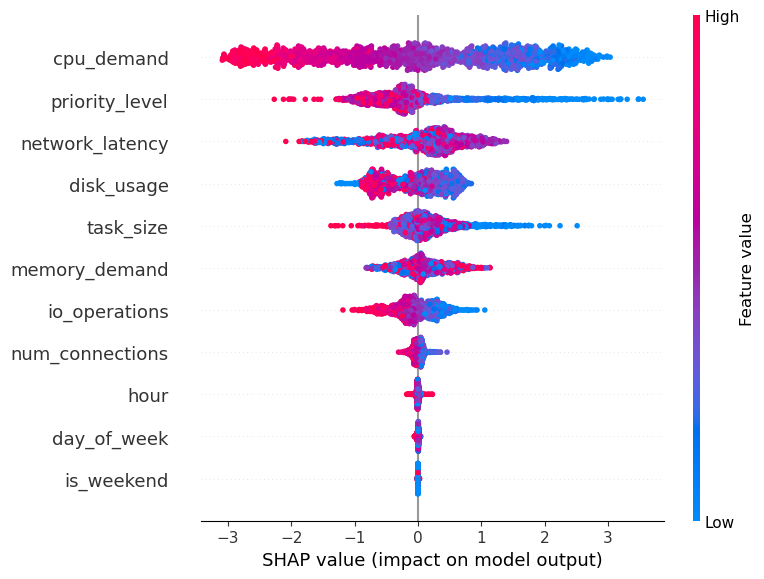

In [9]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_validation)

shap.summary_plot(shap_values, X_validation, feature_names=features)


# Trade-Offs

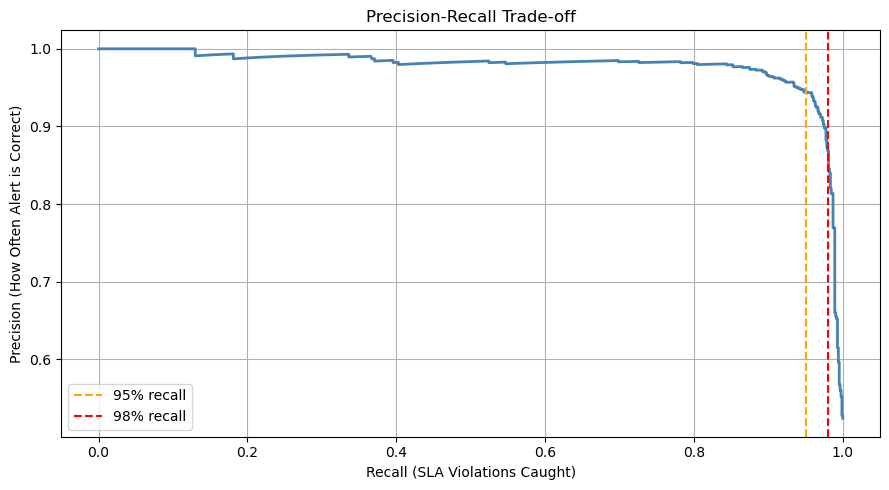

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(recall, precision, lw=2, color='steelblue')
plt.axvline(x=0.95, color='orange', linestyle='--', label='95% recall')
plt.axvline(x=0.98, color='red',    linestyle='--', label='98% recall')
plt.xlabel('Recall (SLA Violations Caught)')
plt.ylabel('Precision (How Often Alert is Correct)')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Model Performance

## 1. Confusion Matrix

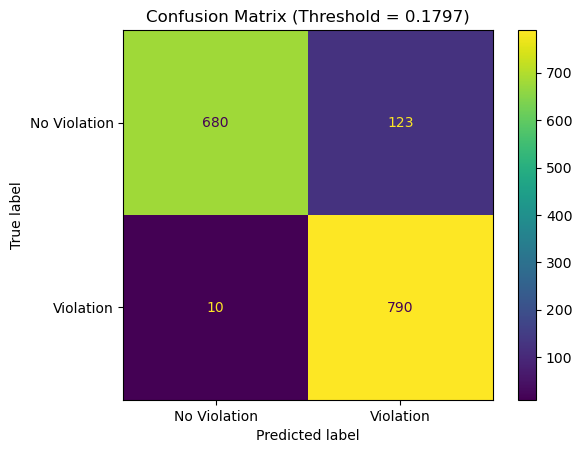

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['No Violation', 'Violation'])
plt.title('Confusion Matrix (Threshold = 0.1797)')
plt.show()


## ROC Curve

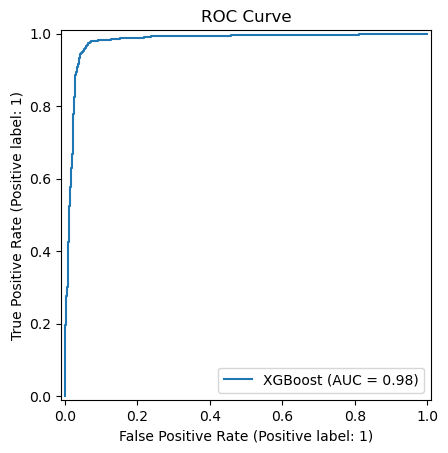

In [15]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, test_probs, name='XGBoost')
plt.title('ROC Curve')
plt.show()


## Precision-Recall Curve

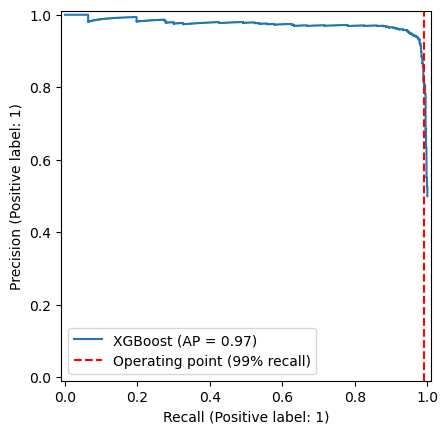

In [16]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, test_probs, name='XGBoost')
plt.axvline(x=0.99, color='red', linestyle='--', label='Operating point (99% recall)')
plt.legend()
plt.show()


## SHAP Waterfall Plot – Single Prediction

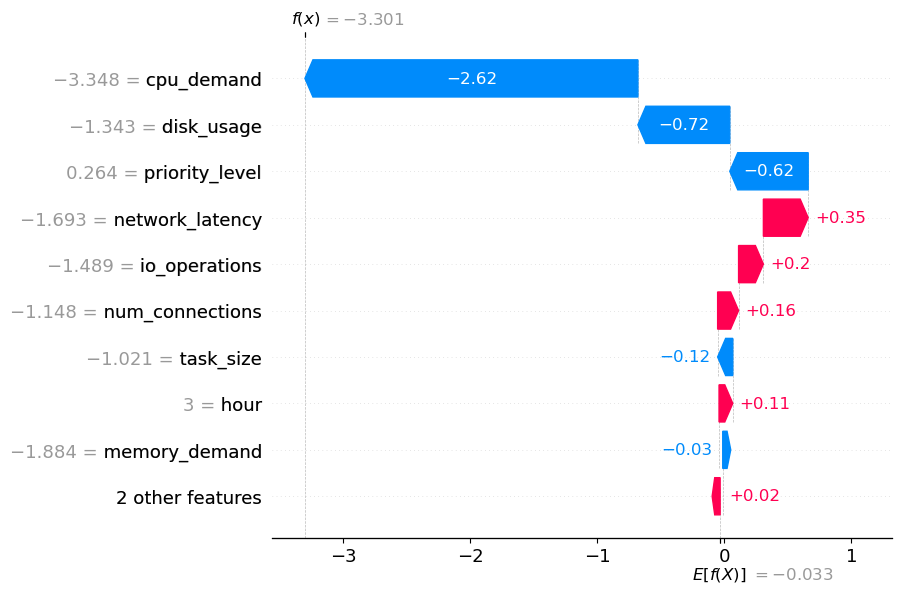

In [17]:
# Inspect the first predicted violation
idx = np.where(test_preds == 1)[0][0]
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=features
))


## SHAP Dependece plot – cpu_demand

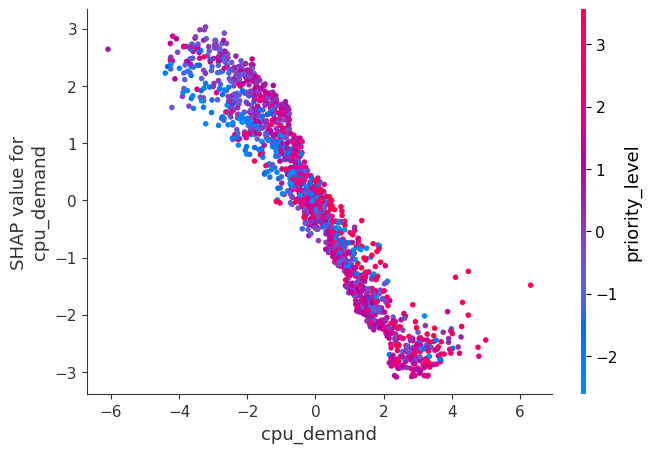

In [18]:
shap.dependence_plot('cpu_demand', shap_values, X_validation,
                     interaction_index='priority_level')


## SHAP Force Plot – Batch View

In [19]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:200], X_validation.iloc[:200])


# Model Internals

## Feature Importance Bar Chart

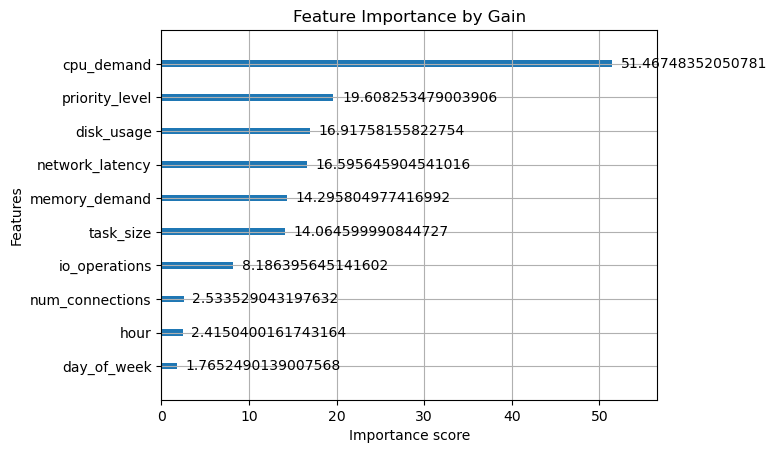

In [20]:
from xgboost import plot_importance
plot_importance(model, importance_type='gain', max_num_features=10)
plt.title('Feature Importance by Gain')
plt.show()


## Early Stopping Learning Curve

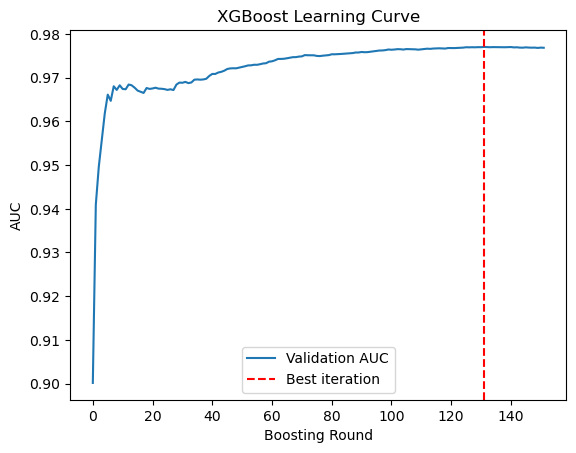

In [21]:
results = model.evals_result()
epochs  = len(results['validation_0']['auc'])

plt.plot(results['validation_0']['auc'], label='Validation AUC')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Learning Curve')
plt.axvline(x=model.best_iteration, color='red', linestyle='--', label='Best iteration')
plt.legend()
plt.show()
